# 설문조사 데이터를 이용한 막대그래프 시각화 알아보기
---
시각화(visualization)란, 어떤 데이터를 사용해서 눈에 보이는 형태로 도표 등을 만드는 작업을 이르는 말입니다. 시각화가 이용되는 업계는 데이터를 사용하는 모든 업계로 확잗되지만, 특히 설문조사 데이터를 다루는 사람들이 자주 사용하는 편이지요. 이번에는 파이썬(Python)을 활용해서 설문조사 데이터를 시각화하는 방법을 소개해 드리도록 하겠습니다. 많은 사람들이 직관적으로 확인할 수 있는 막대그래프(Barplot)에 한해서만 알아볼게요.  
</p></br></br>


## 데이터 소개
---
제품 구매자에게 어떤 요소를 중요하게 생각하는지에 대한 설문조사를 했다고 가정해 봅시다. 아래 데이터는 **성별, 연령대, 연 소득, 가구 형태, 구매 목적, 구매 형태, 구매시 중요하게 생각하는 요소, 구매시 우려하는 부분, 제품 구매 1순위, 제품 구매 2순위** 항목을 저장한 데이터이며, 이 데이터를 시각화할 때는 항목의 응답 분류에 관계없이 모든 데이터를 자동으로 처리하게 코드를 작성해 보겠습니다.  
</p></br></br>



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import koreanize_matplotlib

df = pd.read_csv('./data/구매형태_설문조사.csv')
df.head(3)

,성별,연령대,연 소득,가구 형태,구매 목적,구매 형태,구매시 중요하게 생각하는 요소,구매시 우려하는 부분,제품 구매 1순위,제품 구매 2순위
0,남성,20대,4000만원 미만,1인,취미,신규,가격,가격,가격,옵션의 다양성
1,여성,30대,4000~7000만원,2인,업무,변경,AS,판매처의 신뢰도,환불정책,가격
2,남성,40대,7000만원~1억,3인,기타,추가,기능,유지비,편의성,브랜드


</p></br></br>


## 막대그래프
---
흔히 사용되는 시각화로 막대그래프(bar plot)을 빼놓을 수 없지요. 설문조사 데이터의 특정 항목에서 응답의 비율을 나타내거나, 대소 비교를 해야 하는 데이터를 시각화하는데 이만큼 직관적인 그래프가 없기 때문이지요. 단, 직관적인만큼 알려줄 수 있는 정보가 단순하며 큰 차이를 보이는 데이터와 작은 차이를 보이는 데이터가 혼재되어 있을 경우 시각화의 이점이 사라진다는 단점이 있습니다.
</p></br></br>


파이썬을 이용해서 막대그래프를 그릴 때, 작업을 간소화할 수 있는 부분에 단순 개수 집계가 있습니다. 숫자 형태의 데이터를 시각화할 때는 `sns.barplot(data, x, y)` 와 같이 x, y축 데이터를 지정해 주면 되지만, 이번 데이터와 같이 분류별 개수를 세어야 할 때는 `sns.countplot(data, x)` 를 이용해 보세요. 별도로 항목별 카운트를 하지 않고도 시각화가 가능합니다.  
</p></br></br>



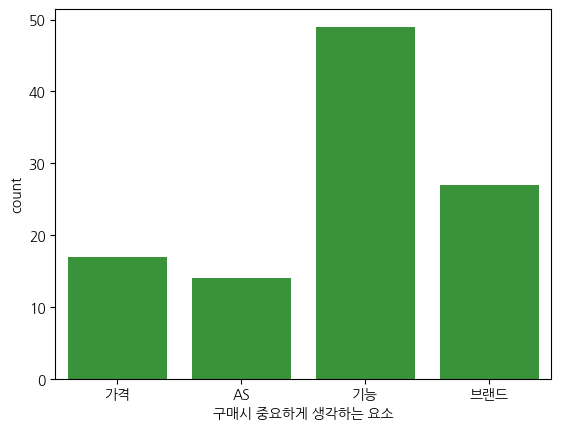

In [2]:
sns.countplot(data=df, x='구매시 중요하게 생각하는 요소', color='tab:green')
plt.show()

</p></br></br>

## Grouped Barplot
---
만약, 세부 항목별 분류를 함께 시각화하고 싶다면 `hue` 매개변수를 이용해 보시기 바랍니다. 이런 방식으로 만들어진 그래프는 Grouped Barplot이라고 합니다.  
</p></br></br>



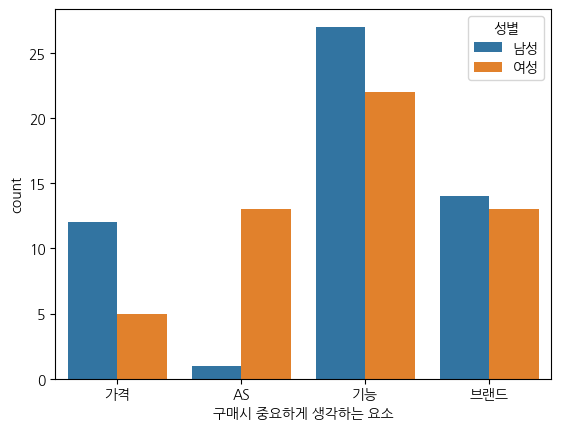

In [3]:
sns.countplot(data=df, x='구매시 중요하게 생각하는 요소', hue='성별')
plt.show()

</p></br></br>


## Stacked Barplot
---
그룹별로 나타나는 막대그래프는 인구 피라미드와 같은 형태의 양방향 막대 그래프로 표현할 수도 있습니다. 가운데 지점을 0으로 잡고, 좌우로 갈수록 늘어나는 축을 활용하면 되는데요, 이 때는 Stacked Barplot과 같은 형태의 표현방법을 활용하면 좋습니다.  
</p></br></br>



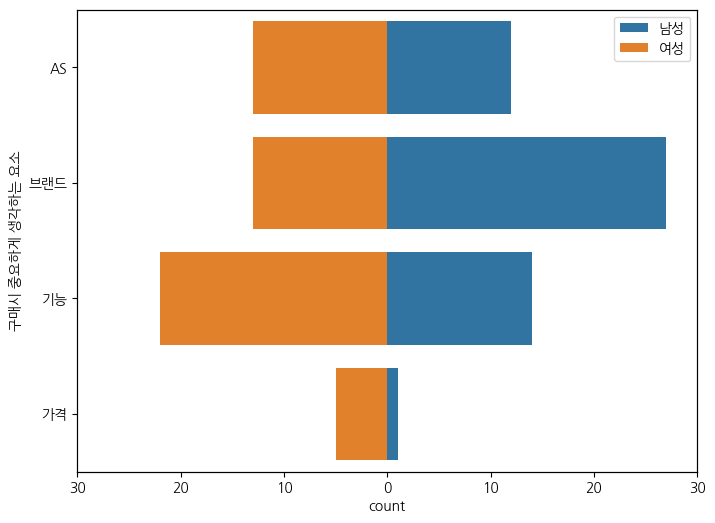

In [4]:
fig, ax1 = plt.subplots(figsize=(8, 6))
sns.countplot(data=df.query("성별 == '남성'"), y='구매시 중요하게 생각하는 요소', color='tab:blue', ax=ax1, label='남성')

ax2 = ax1.twiny()
sns.countplot(data=df.query("성별 == '여성'"), y='구매시 중요하게 생각하는 요소', color='tab:orange', ax=ax2, label='여성')

# 그래프 축 설정
xlim = (-30,30)
ax1.set_xlim(xlim)
ax2.set_xlim(xlim)

ax2.invert_xaxis()

ax1.set_xticklabels([abs(int(i)) for i in plt.xticks()[0]])
ax2.set_xticks([])
ax2.set_xlabel('')

# 그래프 범례
handles, labels = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

handles.extend(handles2)
labels.extend(labels2)

ax1.legend(handles=handles, labels=labels)

plt.show()